# **Deep Learning for Household Food Insecurity Classification and Its Impact on Child Nutrition**

In [54]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


In [55]:
# Load dataset
file_path = "/mnt/data/ml.xlsx"
df = pd.read_excel("/Users/mac/Documents/RESEARCH WORK/ml.xlsx")

# Select relevant features for classification
features = [
    'Sex of household head:', 'Household size:', 'Mother’s occupation:',
    'Mother’s education:', 'Household monthly income:', 'Primary energy source:',
    'Primary source of water:', 'Main type of toilet:',
    'I worry whether my food will run out before I get money to buy more?',
    'The food I bought just didn’t last and I didn’t have money to get more?',
    'I can’t afford to eat balanced meals?',
    'a. In the last 3 months, did you ever cut the size of your meals or skip meals because there wasn’t enough money for food.?',
    'In the last 3 months, did you ever eat less than you felt you should because there wasn’t enough money?',
    'In the last 3 months, were you ever hungry but didn’t eat because you couldn’t afford food?',
    'In the last 3 months, did you lose weight because you didn’t have enough money for food?',
    'WT_CHILD_KG', 'HT_CHILD_', 'MUAC_CHILD_'
]


In [56]:
print(df.columns)


Index(['Sex:', 'Religion:', 'Sex of household head:', 'Household size:',
       'Place of residence:', 'Ethnicity:', 'If others, ',
       'Father’s occupation:', 'Mother’s occupation:', 'Mother’s education:',
       'Household monthly income:', 'Primary energy source:',
       'Primary source of water:', 'Main type of toilet:',
       'What is the position of this baby among your children?',
       'ANC attendance:', 'Place of delivery:',
       'Are you aware of exclusive breastfeeding?',
       'How long after delivery did you first feed your child?',
       'What was the first food your child took?',
       'How many months old was your child when you started giving other foods apart from breast milk?',
       'Are you aware of child growth monitoring?',
       'Did you monitor the growth of your child using a chart?',
       ' Immunization status:',
       'How often has the child fallen ill in the last one month?',
       'Where was the child treated?',
       'I worry whether my

In [57]:
# Drop missing values (alternative: imputation strategies can be applied)
df = df[features].dropna()


In [58]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str)  
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col]) 
    label_encoders[col] = le


In [59]:
# Fill missing values with mode (for categorical) or median (for numerical)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)  # Fill categorical with mode
    else:
        df[col].fillna(df[col].median(), inplace=True)  # Fill numerical with median

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define Food Insecurity as target variable
df['Food Insecurity'] = (
    df[['I worry whether my food will run out before I get money to buy more?',
        'The food I bought just didn’t last and I didn’t have money to get more?',
        'I can’t afford to eat balanced meals?',
        'a. In the last 3 months, did you ever cut the size of your meals or skip meals because there wasn’t enough money for food.?',
        'In the last 3 months, did you ever eat less than you felt you should because there wasn’t enough money?',
        'In the last 3 months, were you ever hungry but didn’t eat because you couldn’t afford food?',
        'In the last 3 months, did you lose weight because you didn’t have enough money for food?']]
    .sum(axis=1) > 2
).astype(int)



In [60]:
# Separate features (X) and target (y)
X = df.drop(columns=['Food Insecurity'])
y = df['Food Insecurity']

# Normalize only numerical columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build deep learning model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')


Epoch 1/50
38/38 [==============================] - 2s 8ms/step - loss: 4.1453 - accuracy: 0.7020 - val_loss: 1.4012 - val_accuracy: 0.8477
Epoch 2/50
38/38 [==============================] - 0s 3ms/step - loss: 2.7781 - accuracy: 0.7036 - val_loss: 0.6747 - val_accuracy: 0.8477
Epoch 3/50
38/38 [==============================] - 0s 5ms/step - loss: 1.7897 - accuracy: 0.7732 - val_loss: 0.4876 - val_accuracy: 0.8477
Epoch 4/50
38/38 [==============================] - 0s 4ms/step - loss: 1.3632 - accuracy: 0.7252 - val_loss: 0.4617 - val_accuracy: 0.8477
Epoch 5/50
38/38 [==============================] - 0s 3ms/step - loss: 1.0188 - accuracy: 0.7682 - val_loss: 0.4834 - val_accuracy: 0.8477
Epoch 6/50
38/38 [==============================] - 0s 4ms/step - loss: 0.7936 - accuracy: 0.7682 - val_loss: 0.4901 - val_accuracy: 0.8477
Epoch 7/50
38/38 [==============================] - 0s 9ms/step - loss: 0.6774 - accuracy: 0.7765 - val_loss: 0.5161 - val_accuracy: 0.8477
Epoch 8/50
38/38 [==

<Figure size 1200x600 with 0 Axes>

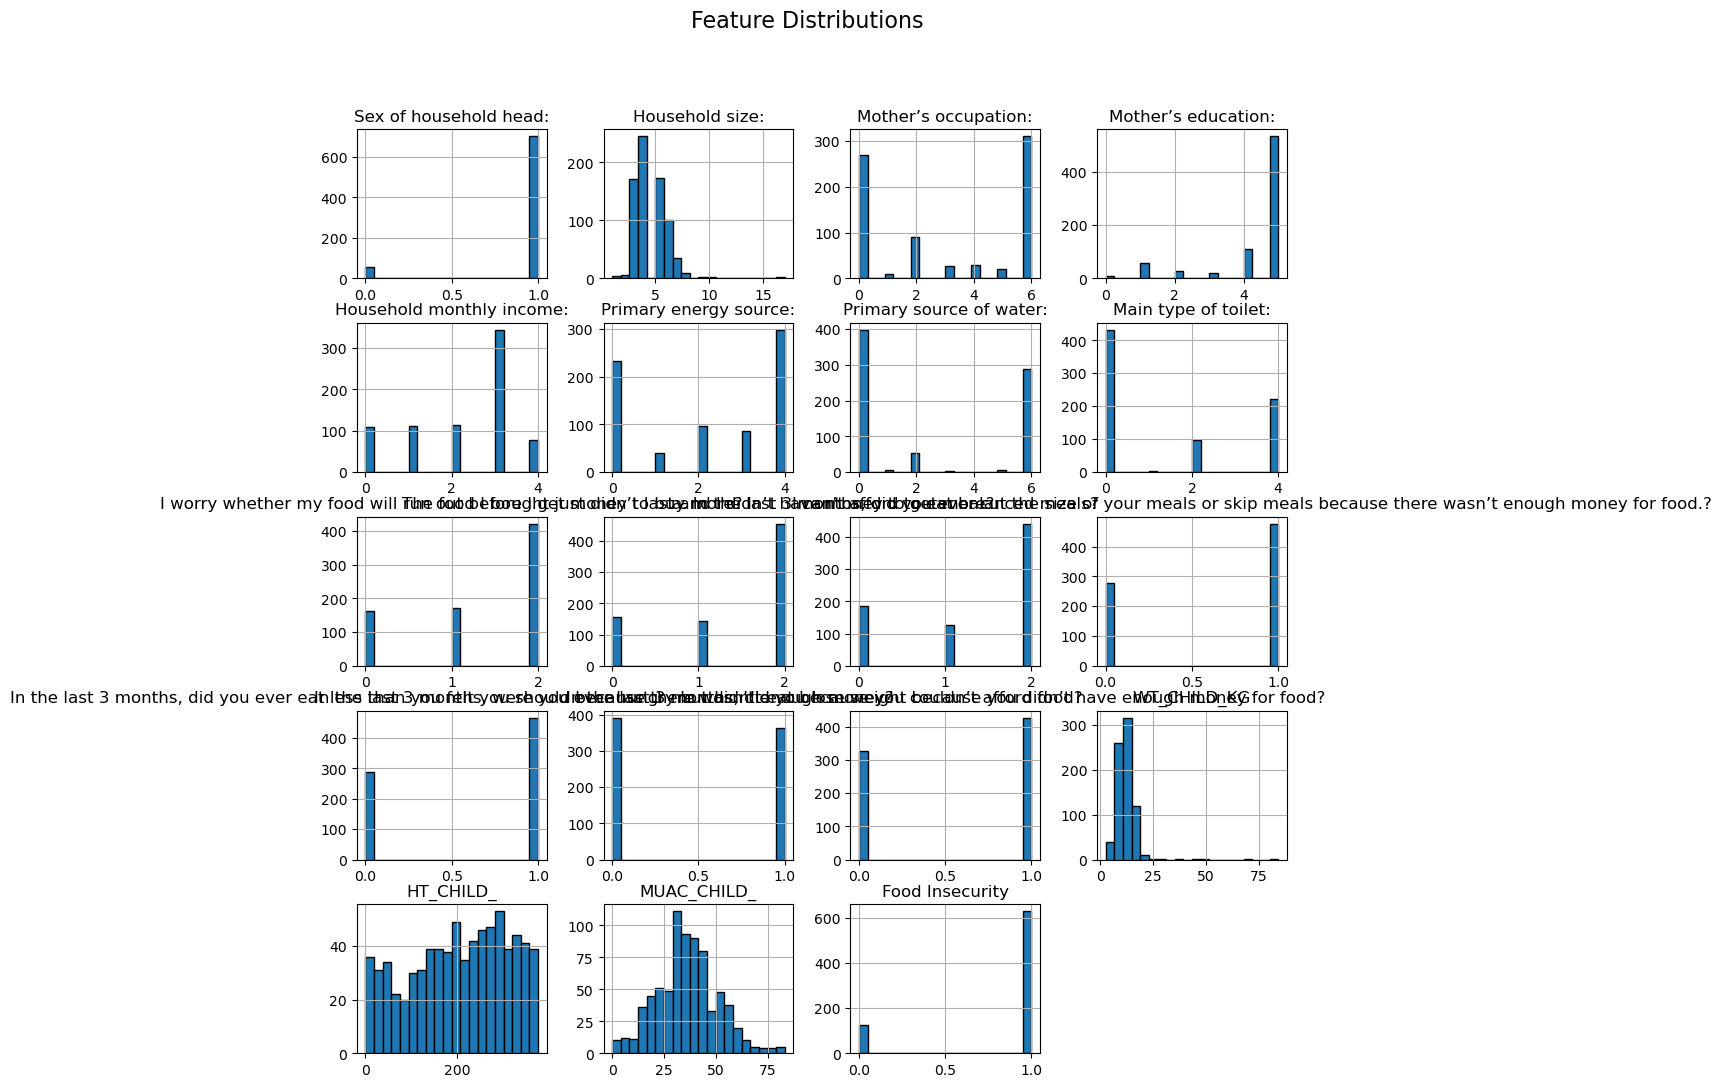

In [61]:
# Visualize feature distributions
plt.figure(figsize=(12, 6))
df.hist(figsize=(12, 12), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()

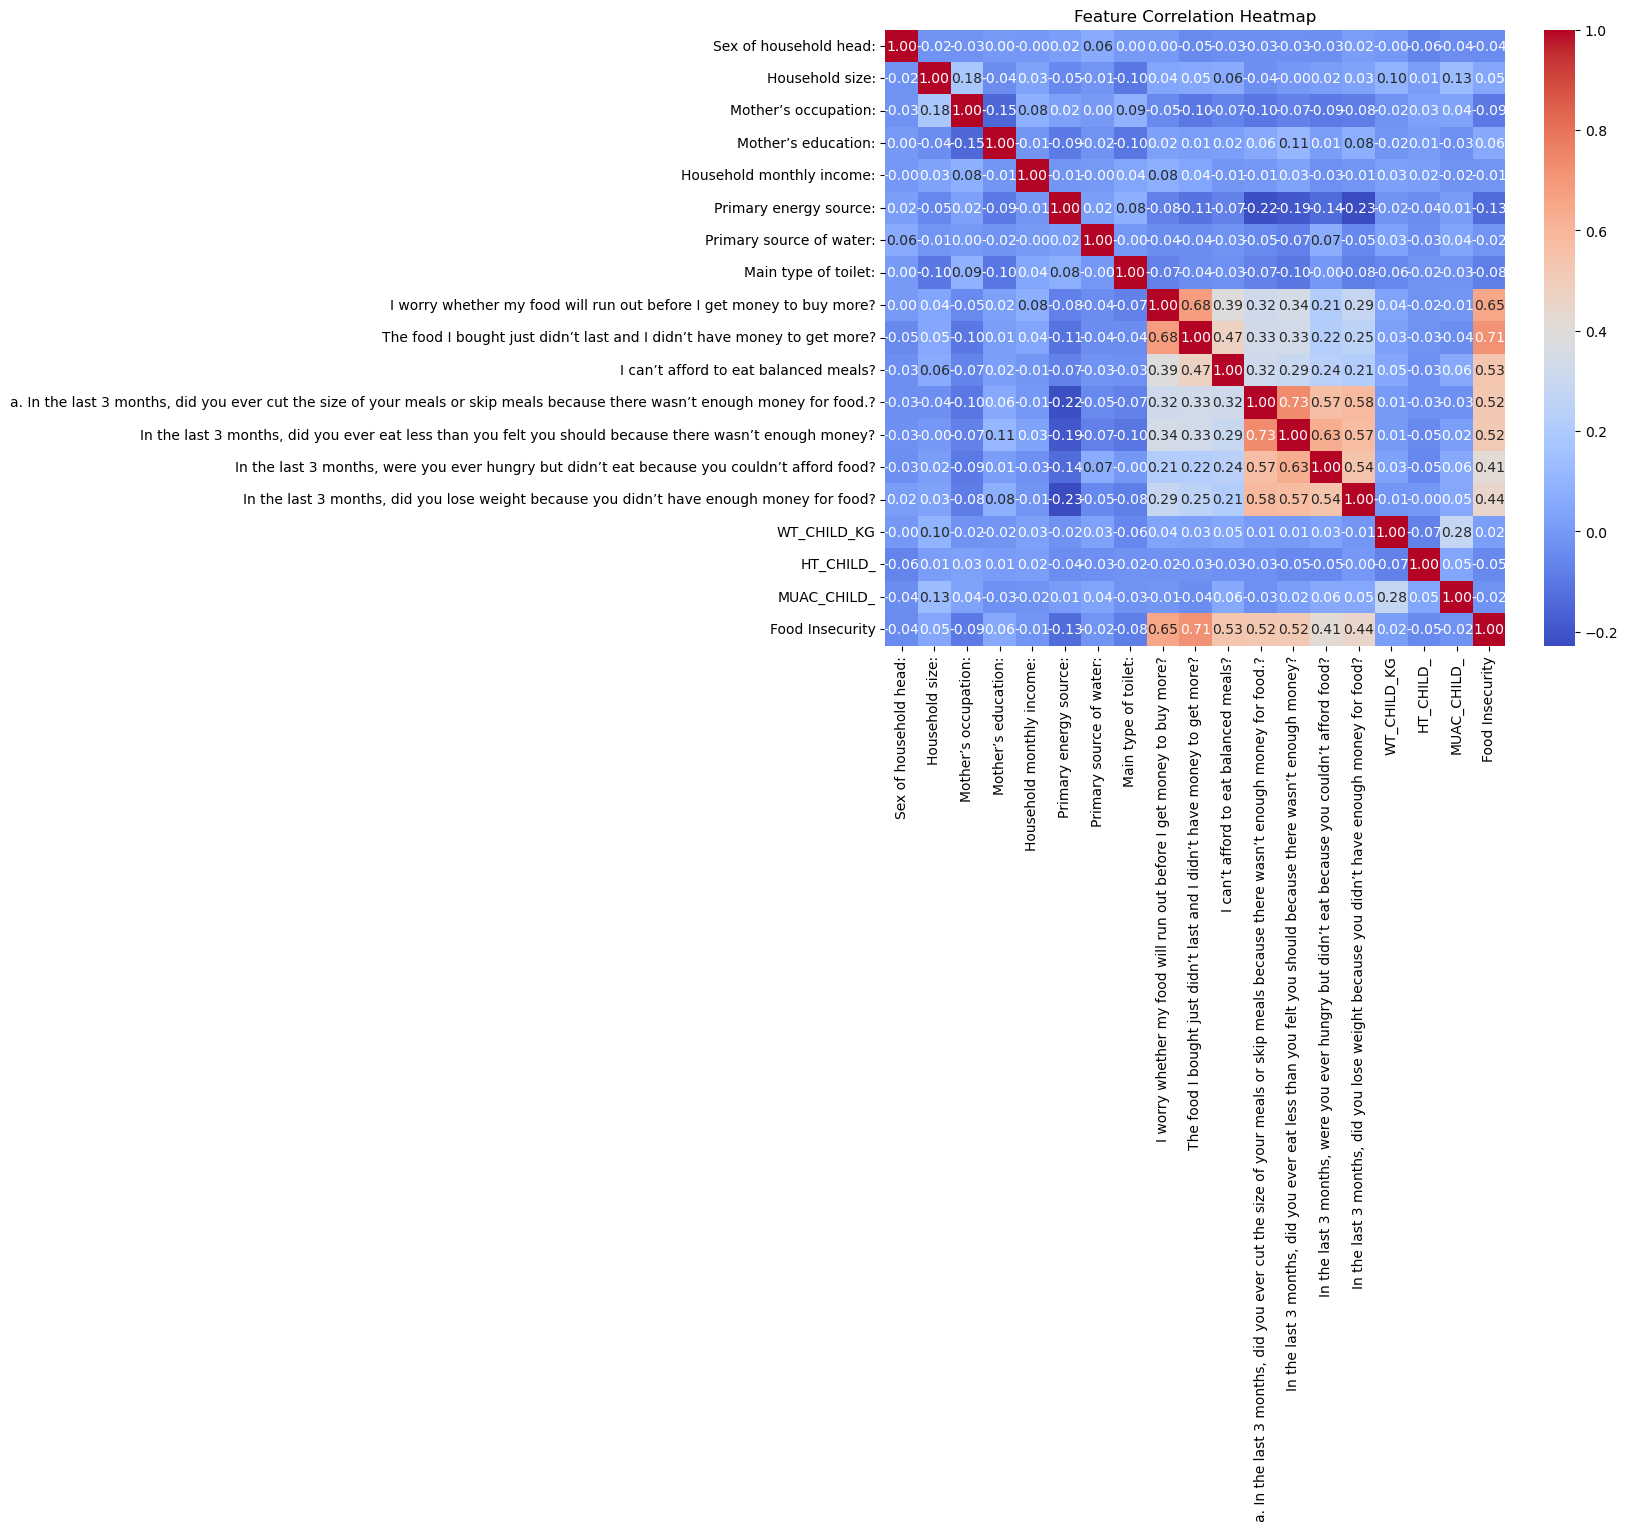

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [63]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separate features (X) and target (y)
X = df.drop(columns=['Food Insecurity'])
y = df['Food Insecurity']

# Normalize numerical columns properly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define model
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model with EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')


Epoch 1/50
38/38 [==============================] - 3s 29ms/step - loss: 1.4270 - accuracy: 0.6159 - val_loss: 1.2150 - val_accuracy: 0.8013
Epoch 2/50
38/38 [==============================] - 0s 9ms/step - loss: 1.1699 - accuracy: 0.7616 - val_loss: 1.0280 - val_accuracy: 0.9470
Epoch 3/50
38/38 [==============================] - 0s 3ms/step - loss: 1.0053 - accuracy: 0.8377 - val_loss: 0.8834 - val_accuracy: 0.9735
Epoch 4/50
38/38 [==============================] - 0s 3ms/step - loss: 0.8885 - accuracy: 0.8675 - val_loss: 0.7763 - val_accuracy: 0.9735
Epoch 5/50
38/38 [==============================] - 0s 3ms/step - loss: 0.8255 - accuracy: 0.9089 - val_loss: 0.6935 - val_accuracy: 0.9868
Epoch 6/50
38/38 [==============================] - 0s 3ms/step - loss: 0.7181 - accuracy: 0.9238 - val_loss: 0.6287 - val_accuracy: 0.9868
Epoch 7/50
38/38 [==============================] - 0s 3ms/step - loss: 0.6758 - accuracy: 0.9454 - val_loss: 0.5755 - val_accuracy: 0.9868
Epoch 8/50
38/38 [=

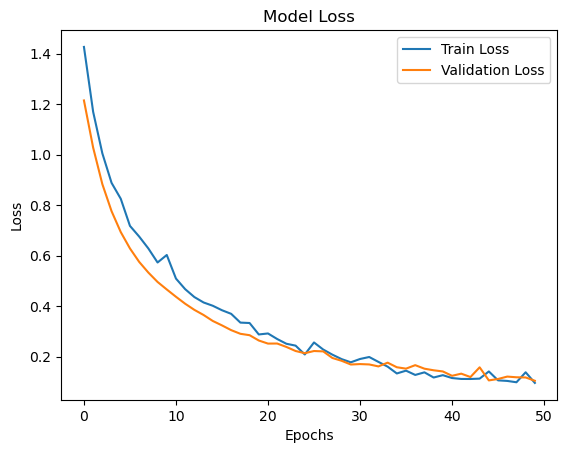

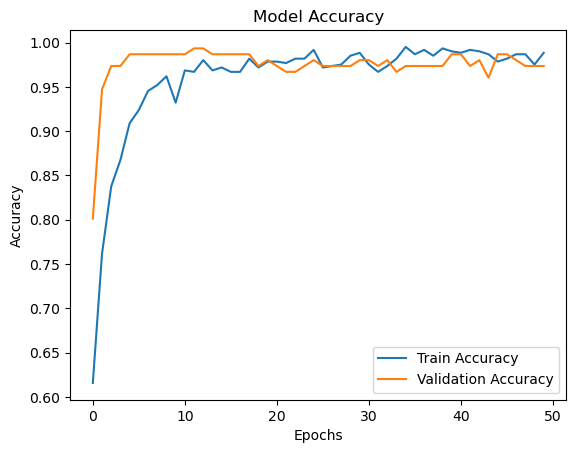

In [65]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [66]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')


5/5 [==============================] - 0s 3ms/step - loss: 0.1045 - accuracy: 0.9735
Test Accuracy: 97.35%


In [67]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = (model.predict(X_test) > 0.5).astype("int32")


print(classification_report(y_test, y_pred))


print(confusion_matrix(y_test, y_pred))


5/5 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        23
           1       0.98      0.98      0.98       128

    accuracy                           0.97       151
   macro avg       0.95      0.95      0.95       151
weighted avg       0.97      0.97      0.97       151

[[ 21   2]
 [  2 126]]
